Fine Tuning Qwen for Customer support - unsloth

In [1]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get('hf_token')
login(hf_token)

In [3]:
pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 kB 7.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 

In [2]:
import pandas as pd
from unsloth import FastLanguageModel
from datasets import load_dataset
from datasets import get_dataset_split_names
import torch



🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00


In [4]:

import evaluate

In [5]:
df = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
df

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})

In [6]:
df['train'][0]

{'flags': 'B',
 'instruction': 'question about cancelling order {{Order Number}}',
 'category': 'ORDER',
 'intent': 'cancel_order',
 'response': "I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you."}

In [7]:
# converting to pandas for preprocessing

df_pandas = df['train'].to_pandas()
df_pandas.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [8]:
df_pandas.duplicated('instruction').sum()

np.int64(2237)

In [9]:
df_pandas=df_pandas.drop_duplicates('instruction')

In [10]:
df_pandas.duplicated('response').sum()

np.int64(0)

In [11]:
df_pandas.isna().sum()

,0
flags,0
instruction,0
category,0
intent,0
response,0


In [12]:
df_pandas['instruction'].str.len().describe()

,instruction
count,24635.000000
mean,47.062837
std,10.874316
min,6.000000
25%,40.000000
50%,48.000000
75%,55.000000
max,92.000000


In [13]:
df_pandas['response'].str.len().describe()

,response
count,24635.000000
mean,628.599351
std,331.398238
min,57.000000
25%,424.000000
50%,537.000000
75%,743.000000
max,2472.000000


In [14]:
df_pandas = df_pandas[df_pandas["response"].str.len() > 12]

In [15]:
df_pandas = df_pandas[df_pandas["instruction"].str.len() > 10]

In [16]:
model_name='Qwen/Qwen2.5-3B-Instruct'

In [17]:
def to_message(row):
  return {
      "messages" :[
          {"role": "user" , "content" : row["instruction"]},
          {"role": "assistant", "content": row["response"]}

      ]
  }



In [18]:
from datasets import Dataset
formatted_df= Dataset.from_pandas(df_pandas).map(to_message,remove_columns=df_pandas.columns.tolist())
formatted_df[0]

Map:   0%|          | 0/24629 [00:00<?, ? examples/s]

{'__index_level_0__': 0,
 'messages': [{'role': 'user',
   'content': 'question about cancelling order {{Order Number}}'},
  {'role': 'assistant',
   'content': "I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you."}]}

In [19]:
from unsloth import FastLanguageModel

model, tokenizer=FastLanguageModel.from_pretrained(model_name, max_seq_length=256, dtype=None, load_in_4bit=True)
model=FastLanguageModel.get_peft_model(model, r=16, lora_alpha=32, lora_dropout=0.05, target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    use_gradient_checkpointing="unsloth")

==((====))==  Unsloth 2026.7.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.7.4 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [20]:
def apply_template(example):
    return {
        "text": tokenizer.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False
        )
    }

formatted_df = formatted_df.map(apply_template)

Map:   0%|          | 0/24629 [00:00<?, ? examples/s]

In [21]:
split1 = formatted_df.train_test_split(test_size=0.1, seed=42) # 10 , 90
split2 = split1["test"].train_test_split(test_size=0.5, seed=42) #10 half

train_df = split1["train"]
val_df = split2["train"]
test_df = split2["test"]

print(len(train_df), len(val_df), len(test_df))

22166 1231 1232


In [22]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

In [23]:
train_df[0]

{'__index_level_0__': 15955,
 'messages': [{'role': 'user',
   'content': 'where do i receive a compensation of moneyh'},
  {'role': 'assistant',
   'content': "I appreciate your inquiry regarding where you can receive compensation for your money. In order to provide you with the most accurate information, could you please provide more details about the specific situation that led to the compensation request? Once I have a better understanding, I can guide you to the appropriate department or process where you can receive the compensation you deserve. Rest assured, I'm here to help you every step of the way and ensure your satisfaction."}],
 'text': "<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nwhere do i receive a compensation of moneyh<|im_end|>\n<|im_start|>assistant\nI appreciate your inquiry regarding where you can receive compensation for your money. In order to provide you with the most accurate information

In [24]:

training_args = SFTConfig(
    output_dir="./qwen-support-unsloth",
    per_device_train_batch_size=8,      # ↑ can go higher — Unsloth uses less VRAM
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,      # ↓ can reduce, since batch size is bigger — same effective batch (16)
    num_train_epochs=1,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=10,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    optim="adamw_8bit",                 # Unsloth-recommended — 8-bit optimizer, saves more memory
    fp16=not is_bfloat16_supported(),   # Unsloth provides this helper — picks the right precision for your GPU
    bf16=is_bfloat16_supported(),
    max_length=256,
    packing=True,                       # Unsloth handles packing efficiently — worth turning on now
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_df,
    eval_dataset=val_df,
    packing=True                       # Unsloth handles packing efficiently — worth turning on now

)

trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/22166 [00:00<?, ? examples/s]

Unsloth: Packing train dataset (num_proc=6):   0%|          | 0/22166 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1231 [00:00<?, ? examples/s]

Unsloth: Packing eval dataset (num_proc=6):   0%|          | 0/1231 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 15,506 | Num Epochs = 1 | Total steps = 970
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
50,0.800203,0.767518
100,0.681045,0.671572
150,0.651859,0.638479
200,0.614827,0.619341
250,0.613080,0.603424
300,0.591953,0.591725
350,0.581932,0.582881
400,0.580610,0.575965
450,0.560185,0.570187
500,0.568197,0.564221


TrainOutput(global_step=970, training_loss=0.6135913450693347, metrics={'train_runtime': 6659.4901, 'train_samples_per_second': 2.328, 'train_steps_per_second': 0.146, 'total_flos': 5.933519342584627e+16, 'train_loss': 0.6135913450693347, 'epoch': 1.0})

In [25]:
trainer.save_model("./qwen-support-unsloth/final_adapter")
tokenizer.save_pretrained("./qwen-support-unsloth/final_adapter")

Unsloth: Restored added_tokens_decoder metadata in ./qwen-support-unsloth/final_adapter/tokenizer_config.json.


('./qwen-support-unsloth/final_adapter/tokenizer_config.json',
 './qwen-support-unsloth/final_adapter/chat_template.jinja',
 './qwen-support-unsloth/final_adapter/tokenizer.json')

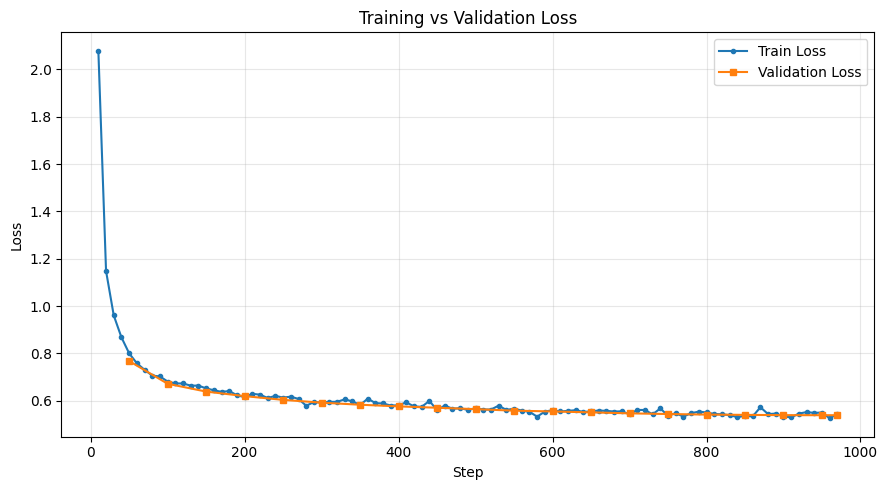

In [26]:
import matplotlib.pyplot as plt

# Extract logs from the trainer's history
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

plt.figure(figsize=(9, 5))
plt.plot(train_steps, train_losses, label="Train Loss", color="tab:blue", marker="o", markersize=3)
plt.plot(eval_steps, eval_losses, label="Validation Loss", color="tab:orange", marker="s", markersize=4)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

In [41]:
from transformers import pipeline
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=256,
    dtype=None,
    load_in_4bit=True)

FastLanguageModel.for_inference(base_model)   # enables Unsloth's fast inference path

base_pipe = pipeline("text-generation", model=base_model, tokenizer=tokenizer, max_new_tokens=150)

# --- Fine-tuned model ---
ft_model = PeftModel.from_pretrained(base_model, "./qwen-support-unsloth/final_adapter")  # match your actual checkpoint folder
FastLanguageModel.for_inference(ft_model)

ft_pipe = pipeline("text-generation", model=ft_model, tokenizer=tokenizer, max_new_tokens=150)

test_prompts = [
    "I want to cancel my order, how do I do that?",
    "My package arrived damaged, what should I do?",
    "Can I get a refund for my subscription?",
]

for prompt in test_prompts:
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    print("PROMPT:", prompt)
    print("BASE:", base_pipe(formatted)[0]["generated_text"][len(formatted):])
    print("FINE-TUNED:", ft_pipe(formatted)[0]["generated_text"][len(formatted):])

==((====))==  Unsloth 2026.7.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: I want to cancel my order, how do I do that?


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

BASE: I'm sorry to hear that your package arrived damaged. I understand how frustrating this can be, but rest assured, we're here to help you resolve the issue. To ensure that we address your concerns effectively, could you please provide us with some additional details about the damage? This will allow us to investigate the matter thoroughly and find the best solution for you. Your satisfaction is our top priority, and we appreciate your patience as we work towards resolving this issue.


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FINE-TUNED: I'm sorry to hear that your package arrived damaged. We take this issue seriously and want to assist you in resolving it as quickly as possible. To get started, could you please provide us with the tracking number or any other relevant details about your package? With this information, we can investigate the matter further and work towards finding a suitable solution for you. Thank you for bringing this to our attention, and we appreciate your patience as we address this concern together.
PROMPT: Can I get a refund for my subscription?


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE: I've grasped that you're seeking information about obtaining a refund for your subscription. Rest assured, I'm here to assist you in the best possible way. To proceed with your request, could you please provide me with some additional details? Specifically, it would be helpful if you could let me know the reason for your dissatisfaction and any relevant order or transaction numbers. This will enable me to gather the necessary information and guide you through the process of initiating a refund. Your satisfaction is our top priority, and I'll do everything I can to ensure that your concerns are addressed promptly and efficiently.
FINE-TUNED: I'll take care of it! I understand that you're looking to obtain a refund for your subscription. To assist you further, could you please provide me with some additional details about the subscription you would like to request a refund for? This will help me guide you through the process and ensure that you receive the appropriate assistance. R

In [42]:
import gradio as gr

def respond(message, history):
    messages = [{"role": "user", "content": message}]
    formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    output = ft_pipe(formatted)[0]["generated_text"][len(formatted):]
    return output

gr.ChatInterface(respond).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c328495761809edcf.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
